In [ ]:
# Notebook setup
import sys
from pathlib import Path
base = Path.cwd()
source = next((p for p in (base, *base.parents) if (p / "code/pyproject.toml").is_file()), base / "Release-Client.zip")
if not source.exists() and "google.colab" in sys.modules:
    from google.colab import files
    print("Required file: Release-Client.zip (project code). Choose this ZIP; data files are requested next.", flush=True)
    files.upload(target_dir=str(base))
if not source.exists():
    raise FileNotFoundError("Supply Release-Client.zip, or open the extracted code/notebooks folder.")
sys.path.insert(0, str(source / "cost-aware-market-forecasting" if source.is_file() else source))
sys.modules.pop("run_zip", None)
from run_zip import prepare_reader
CODE = CODE_ROOT = prepare_reader('08_RQ2_C_BTC_qualified_union_ensemble.ipynb', source, ())

# 08 - RQ2_C: BTC Qualified Union ensemble

## Methodology

Qualified Union v1 combines no-sentiment LSTM DZ55 and Linear SVM DZ75. Either member can supply a directional signal; opposite signals veto the trade. Member thresholds stay fixed at 0.75 for LSTM and 0 for SVM. Trades use TP200/SL100, a one-M15 maximum hold and 5 bps per side, without learned ensemble weights.

H1-2025 provides construction evidence, separate from the July 2025 to March 2026 replay. The latter remains development-forward evidence because the underlying models were inspected previously. Q2-2026 performance is reported separately in Notebook 22.

In [2]:
import hashlib
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CACHE = CODE_ROOT / 'experiments' / 'cache' / 'qualified_union_v1'
LOCKBOX = pd.Timestamp('2026-04-01', tz='UTC')

def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

protocol = json.loads((CACHE / 'protocol.json').read_text(encoding='utf-8'))
manifest = json.loads((CACHE / 'manifest.json').read_text(encoding='utf-8'))
for filename, expected in manifest['artifact_hashes'].items():
    assert sha256(CACHE / filename) == expected, filename
assert protocol['protocol_version'] == 'qualified-union-v1'
assert manifest['forward_replay_count'] == 1
assert protocol['lockbox_2026_q2_used'] is False

## 1. Ensemble construction

The members retain their fixed class and confidence rules. SVM uses `tau=0`, so class-preserving temperature scaling cannot change its signals.

In [3]:
from IPython.display import Markdown
membership = pd.DataFrame(protocol['members'])
execution = pd.DataFrame([protocol['execution']])
display(Markdown('Member labels and confidence gates are read from the frozen Union protocol.'))
display(membership)
display(Markdown('The same execution contract applies to both members after the agreement rule.'))
display(execution)

Member labels and confidence gates are read from the frozen Union protocol.

,model,tau,width_bps
0,lstm,0.75,55
1,svm_linear,0.00,75


The same execution contract applies to both members after the agreement rule.

,fee_bps_per_side,max_hold,sl_bps,tp_bps
0,5.0,1,100,200


## 2. H1 construction evidence

The table reports the January to June 2025 construction sample separately from the development-forward replay.

In [4]:
from IPython.display import Markdown
summary = pd.read_csv(CACHE / 'summary.csv').set_index('phase')
monthly = pd.read_csv(CACHE / 'monthly.csv')
h1 = summary.loc[['h1']]
display(Markdown('The Union rule is replayed on H1 solely as construction evidence.'))
display(h1.round(4))
assert int(h1.iloc[0]['trades']) == 88

The Union rule is replayed on H1 solely as construction evidence.

,period_start,period_end_exclusive,trades,long_trades,short_trades,gross_return,gross_bps_per_trade,net_return,sortino,sharpe,max_drawdown
phase,,,,,,,,,,,
h1,2025-01-01T00:00:00+00:00,2025-07-01T00:00:00+00:00,88,56,32,0.0977,11.1009,0.0097,0.3521,0.2134,0.0476


## 3. Development-forward performance

The unchanged union rule is evaluated from July 2025 to March 2026. Net return is additive and expressed as a fraction, so 0.01 denotes 1%.

Frozen complementary signals are replayed on July 2025–March 2026 after registered costs.

,period_start,period_end_exclusive,trades,long_trades,short_trades,gross_return,gross_bps_per_trade,net_return,sortino,sharpe,max_drawdown
phase,,,,,,,,,,,
forward,2025-07-01T00:00:00+00:00,2026-04-01T00:00:00+00:00,74,32,42,0.1371,18.5337,0.0631,2.1061,1.165,0.0298


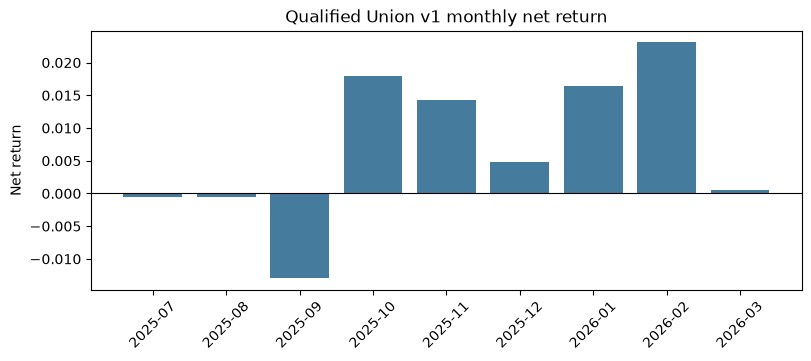

In [5]:
from IPython.display import Markdown
forward = summary.loc[['forward']]
display(Markdown('Frozen complementary signals are replayed on July 2025–March 2026 after registered costs.'))
display(forward.round(4))
row = forward.iloc[0]
assert int(row['trades']) == 74
assert int(row['long_trades']) == 32 and int(row['short_trades']) == 42
assert abs(float(row['net_return']) - 0.06315) < 5e-5

forward_monthly = monthly.loc[monthly['phase'].eq('forward')].copy()
fig, ax = plt.subplots(figsize=(8.0, 3.5), layout='constrained')
ax.bar(forward_monthly['month'], forward_monthly['net_return'], color='#457b9d')
ax.axhline(0, color='black', linewidth=.8)
ax.set_title('Qualified Union v1 monthly net return')
ax.set_ylabel('Net return')
ax.tick_params(axis='x', rotation=45)
plt.show()

## Results

Qualified Union v1 produces 74 development-forward trades: 32 LONG and 42 SHORT. The saved table reports net return of approximately +6.31%, Sortino 2.1061 and Sharpe 1.165 after round-trip costs. H1 construction evidence contains 88 trades and a smaller positive net return; it is not an independent test.

Takeaway: The two-member union is profitable in this development-forward sample, but the limited trade count and earlier model inspection constrain generalisation.